# 07 · Pipeline — what is being built

Sources: OpenStreetMap India via Geofabrik (ODbL) · MoRTH Annual Report 2024-25, Appendix-2 (as on 31.12.2024) · WorldPop 2020 1 km (CC BY 4.0) · GHSL built-up (CC BY 4.0) · MoRTH Road Accidents in India 2024 · NHAI Datalake — aggregates only (ADR-0014). Rebuild everything: `cd ml && uv run python -m fields.national_highways all`.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ML = Path.cwd().resolve().parents[1]  # ml/notebooks/national_highways -> ml
sys.path.insert(0, str(ML))
from fields.national_highways import analysis as nh

A = nh.A
SUMMARY = json.loads((A / "summary.json").read_text())
pd.set_option("display.max_rows", 40)
pd.set_option("display.float_format", "{:,.2f}".format)
plt.rcParams.update({"figure.dpi": 80, "figure.figsize": (9, 4.5), "axes.spines.top": False, "axes.spines.right": False})

In [2]:
pipe = pd.read_csv(A / "pipeline_by_state.csv", index_col=0)
display(pipe.loc[["India"]])
pipe.drop("India").sort_values("nhai_greenfield_km", ascending=False).head(15)

,osm_proposed,osm_under_construction,nhai_target_FY - 23,nhai_target_FY - 24,nhai_target_FY - 25,nhai_target_FY - 26,nhai_greenfield_km
state,,,,,,,
India,"2,750.00","8,695.00","1,200.00","2,657.00","4,320.00","3,196.00","11,351.00"


,osm_proposed,osm_under_construction,nhai_target_FY - 23,nhai_target_FY - 24,nhai_target_FY - 25,nhai_target_FY - 26,nhai_greenfield_km
state,,,,,,,
Maharashtra,266.00,"1,638.00",0.00,977.00,0.00,728.00,"1,704.00"
Uttar Pradesh,3.00,"1,262.00",294.00,28.00,"1,068.00",71.00,"1,460.00"
Andhra Pradesh,0.00,573.00,0.00,91.00,596.00,434.00,"1,121.00"
Rajasthan,0.00,74.00,306.00,712.00,9.00,0.00,"1,026.00"
Gujarat,0.00,196.00,0.00,513.00,105.00,280.00,876.00
Punjab,0.00,"1,071.00",0.00,0.00,743.00,111.00,854.00
Madhya Pradesh,0.00,215.00,243.00,0.00,190.00,285.00,718.00
Haryana,0.00,187.00,335.00,16.00,205.00,69.00,625.00
Telangana,592.00,115.00,0.00,0.00,367.00,217.00,584.00


In [3]:
pd.read_csv(A / "nhai_project_stages.csv", index_col=0).round(0)

,projects,km
current_st,,
Under Construction (AD issued),353,"13,603.00"
CC Issued & O&M by Construction Agency,263,"17,365.00"
"PCC Issued, CC Pending",114,"7,622.00"
Under O&M through OMT/TOT/O&M Agency at Site,74,"6,173.00"
Balance for Award,73,"6,099.00"
"Awarded, Not Appointed",61,"2,244.00"
Completed & Agency Demobilised (Civil/O&M),31,"1,682.00"
Terminated,23,"1,519.00"
O&M on Project no more required,18,566.00


In [4]:
acc = pd.read_csv(A / "access_by_state.csv", index_col=0)
acc.drop("India").sort_values("people_gaining_10km", ascending=False).head(12)[["population", "share_within_10km_now", "share_within_10km_future", "people_gaining_10km"]]

,population,share_within_10km_now,share_within_10km_future,people_gaining_10km
state,,,,
Uttar Pradesh,"231,371,334.16",0.83,0.85,"4,623,008.46"
Karnataka,"68,794,054.64",0.75,0.78,"2,464,192.92"
West Bengal,"99,347,606.15",0.74,0.76,"1,964,052.92"
Punjab,"30,766,311.06",0.88,0.93,"1,664,523.79"
Bihar,"125,437,316.79",0.85,0.86,"1,638,623.49"
Maharashtra,"126,152,132.95",0.88,0.89,"1,336,027.98"
Telangana,"38,980,515.03",0.81,0.84,"1,285,834.42"
Kerala,"33,855,203.49",0.80,0.83,"1,079,424.79"
Tamil Nadu,"80,916,392.68",0.82,0.83,"954,515.35"


## Schedule and delay flags
Source: the NHAI dashboard layer (`adv_upc_wise_alignments_wfs_layers`), read-only, aggregates only (ADR-0014). A project under construction whose **scheduled completion date has passed** is *overdue*; a project **awarded but never appointed** is *not started* (days since its letter of award are the driver). Projects holding a provisional completion certificate are not assessed: the layer has no certificate date, so a passed schedule would prove nothing. There is deliberately no "behind plan" score — progress follows an S-curve, and a straight-line benchmark labels most healthy projects behind.

NHAI's static website lists (`get_ui_projects.json` and its siblings) are **not used**: their newest award and appointment dates are from September 2021, and their stage labels agree with the live layer for only 7% of shared projects.

In [5]:
from fields.national_highways import schedule as sched

delays = pd.read_csv(A / "delay_by_state.csv", index_col=0)
india = delays.loc["India"]
print(f"As of {sched.as_of_date()}: {india.under_construction:,.0f} NHAI projects under construction; "
      f"{india.overdue:,.0f} ({india.overdue_share:.0%} of those with a schedule) are past their scheduled completion, "
      f"a median {india.median_days_overdue:,.0f} days late and {india.median_physical_pct_overdue:.0f}% built. "
      f"{india.not_started:,.0f} awarded projects have not started (median {india.median_days_since_loa_not_started:,.0f} days since award).")
delays.loc[["India"]]

As of 2026-09-29: 388 NHAI projects under construction; 264 (68% of those with a schedule) are past their scheduled completion, a median 572 days late and 82% built. 28 awarded projects have not started (median 237 days since award).


,under_construction,overdue,scheduled_ahead,unknown,not_started,overdue_share,median_days_overdue,median_physical_pct_overdue,median_days_since_loa_not_started,capex_under_construction_cr,capex_overdue_cr
India,388,264,123,1,28,0.68,572.00,81.50,237.00,487217,328950


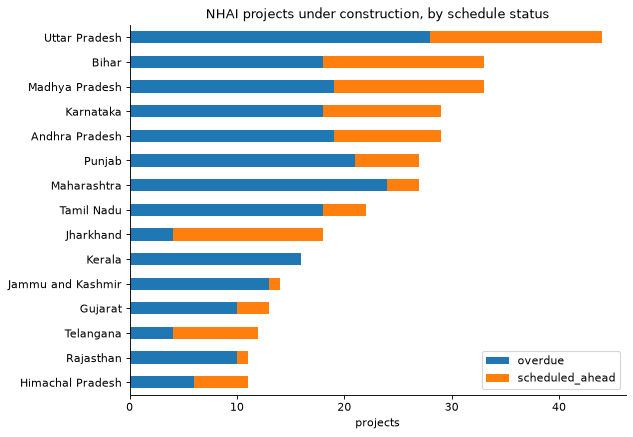

In [6]:
top = delays.drop("India").head(15).iloc[::-1]
ax = top[["overdue", "scheduled_ahead"]].plot.barh(stacked=True, figsize=(8, 6), title="NHAI projects under construction, by schedule status")
ax.set_xlabel("projects"); ax.set_ylabel("");

In [7]:
delays.drop("India").query("under_construction >= 10").sort_values("overdue_share", ascending=False)[["under_construction", "overdue", "overdue_share", "median_days_overdue", "median_physical_pct_overdue"]]

,under_construction,overdue,overdue_share,median_days_overdue,median_physical_pct_overdue
Kerala,16,16,1.00,615.00,81.89
Jammu and Kashmir,14,13,0.93,733.00,74.63
Rajasthan,11,10,0.91,347.50,92.31
Maharashtra,27,24,0.89,692.00,87.93
Tamil Nadu,22,18,0.82,645.00,80.28
Punjab,28,21,0.78,623.00,73.35
Gujarat,13,10,0.77,665.00,86.31
Andhra Pradesh,29,19,0.66,232.00,67.05
Uttar Pradesh,44,28,0.64,434.50,85.62
Karnataka,29,18,0.62,558.00,83.07


### What could not be read
Every unreadable value is listed with its reason and left unflagged — a scheduled date outside 2000–2040 (the layer holds a 1999 and a 2051 date), a missing stage label, a project across several states (grouped as *Multiple states*).

In [8]:
pd.read_csv(nh.OUT / "nhai_schedule_errors.csv")["reason"].value_counts()

reason
unknown_stage             19
scheduled_out_of_range    18
loa_out_of_range          10
appointed_out_of_range     9
no_scheduled_date          1
Name: count, dtype: int64

## Cited events from MoRTH press releases
Source: the MoRTH press-release listing and each release's page on PIB (Government of India, PIB Copyright Policy: free reproduction with the source acknowledged). Rules, not a model: a release becomes an event when its title matches a stage rule and one sentence of its opening paragraphs states the stage. That sentence is the evidence quote, copied verbatim and re-checked against the page; NH refs, states, cost and length are read from the title and that sentence only. Every listed release appears below with its outcome — nothing is dropped.

In [9]:
press = pd.read_csv(nh.OUT / "press_releases.csv")
press["classification"].value_counts()

classification
no_project_event        125
event                    22
no_release_text           4
unsupported_language      3
Name: count, dtype: int64

In [10]:
events = pd.read_parquet(nh.OUT / "nh_events.parquet").sort_values("event_date", ascending=False)
display(events.groupby(["stage", "event_type"]).size().rename("events"))
events[["event_date", "event_type", "nh_refs", "states", "cost_crore", "length_km", "confidence"]]

stage               event_type           
approved            cabinet_approval         9
                    cabinet_cost_revision    1
                    minister_approval        1
proposed            dpr_preparation          1
tendered            bids_received            4
                    contract_awarded         5
under_construction  tunnel_breakthrough      1
Name: events, dtype: int64

,event_date,event_type,nh_refs,states,cost_crore,length_km,confidence
0,2026-09-01,bids_received,[],[Odisha],NaN,160.00,0.80
1,2026-08-19,cabinet_approval,[NH22],[Bihar],"3,590.73",NaN,0.90
2,2026-07-28,dpr_preparation,[NH148NA],[],NaN,NaN,0.80
3,2026-07-01,cabinet_approval,[NH34],[Uttar Pradesh],"7,145.14",117.70,0.90
4,2026-07-01,cabinet_approval,"[NH148AE, NH248BB]",[Delhi],"6,969.67",8.10,0.90
5,2026-06-09,tunnel_breakthrough,[],"[Jammu and Kashmir, Ladakh]",NaN,NaN,0.80
6,2026-06-03,cabinet_approval,[NH347B],[Madhya Pradesh],"4,415.60",NaN,0.90
7,2026-06-03,cabinet_approval,[],[Odisha],"8,300.79",NaN,0.85
8,2026-06-03,cabinet_approval,"[NH31, NH231]",[Bihar],"3,936.05",143.53,0.90
9,2026-06-03,cabinet_approval,"[NH63, NH563]",[Telangana],"7,597.16",190.76,0.90


In [11]:
for _, r in events.head(3).iterrows():
    print(f"{r.event_date} · {r.event_type} · {r.source_url}")
    print("   ", r.evidence, "\n")

2026-09-01 · bids_received · https://pib.gov.in/PressReleasePage.aspx?PRID=2305502
    National Highways Authority of India (NHAI) has received an overwhelming response from the bidders for the implementation of 160 km long Access Controlled Greenfield Coastal National Highway from Rameshwar to Paradeep in Odisha. 

2026-08-19 · cabinet_approval · https://pib.gov.in/PressReleasePage.aspx?PRID=2301145
    The Cabinet Committee on Economic Affairs, chaired by the Prime Minister Shri Narendra Modi, today has approved the Upgradation of the Muzaffarpur-Sitamarhi-Sonbarsa Section of NH-22 to four-Lane Standard in Bihar. 

2026-07-28 · dpr_preparation · https://pib.gov.in/PressReleasePage.aspx?PRID=2290462
    In order to improve traffic flow and enhance commuter convenience in the National Capital Region (NCR), NHAI has undertaken preparation of the Detailed Project Report (DPR) to address traffic congestion at the Sarai Kale Khan Loop, which is a critical junction of the DND–Sohna section 

### Coverage
The listing holds about seven months of MoRTH releases (March–September 2026). Stage events are sparse — about one release in seven — because most releases are about tolling, safety, policy and ministerial reviews. Hindi releases are listed but not extracted, and the news and tender feeds are not built (see the field plan).